## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve

## Load final results

In [2]:
results_df = pd.read_csv("../data/processed/model_predictions.csv")

results_df.head()

,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,...,pub_rec,revol_bal,revol_util,total_acc,earliest_cr_line,application_type,addr_state,actual_default,log_pred_prob,lgbm_pred_prob
0,3000.0,36 months,7.34,A,A4,9 years,RENT,52000.0,Source Verified,major_purchase,...,0.0,141.0,0.5,30.0,Jan-1998,Individual,WA,0,0.042403,0.035067
1,5000.0,36 months,11.98,B,B5,10+ years,OWN,55000.0,Not Verified,other,...,1.0,11449.0,33.9,24.0,Aug-2001,Individual,GA,0,0.120263,0.117163
2,7000.0,36 months,11.98,B,B5,< 1 year,MORTGAGE,40000.0,Verified,home_improvement,...,0.0,5004.0,36.0,29.0,Mar-2007,Individual,TX,0,0.149245,0.131902
3,20300.0,60 months,17.47,D,D1,< 1 year,RENT,55000.0,Verified,credit_card,...,0.0,17506.0,70.9,26.0,Nov-2007,Individual,NY,1,0.403366,0.420887
4,30000.0,36 months,21.85,D,D5,10+ years,OWN,57000.0,Verified,debt_consolidation,...,0.0,29222.0,53.2,26.0,Apr-2000,Individual,FL,0,0.253278,0.251556


## Final model performance summary

In [3]:
from sklearn.metrics import roc_auc_score

y_test = results_df["actual_default"]
log_pred_prob = results_df["log_pred_prob"]
lgbm_pred_prob = results_df["lgbm_pred_prob"]

log_auc = roc_auc_score(y_test, log_pred_prob)
lgbm_auc = roc_auc_score(y_test, lgbm_pred_prob)

performance_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "LightGBM"],
    "ROC_AUC": [log_auc, lgbm_auc]
})

performance_summary

,Model,ROC_AUC
0,Logistic Regression,0.694323
1,LightGBM,0.702558


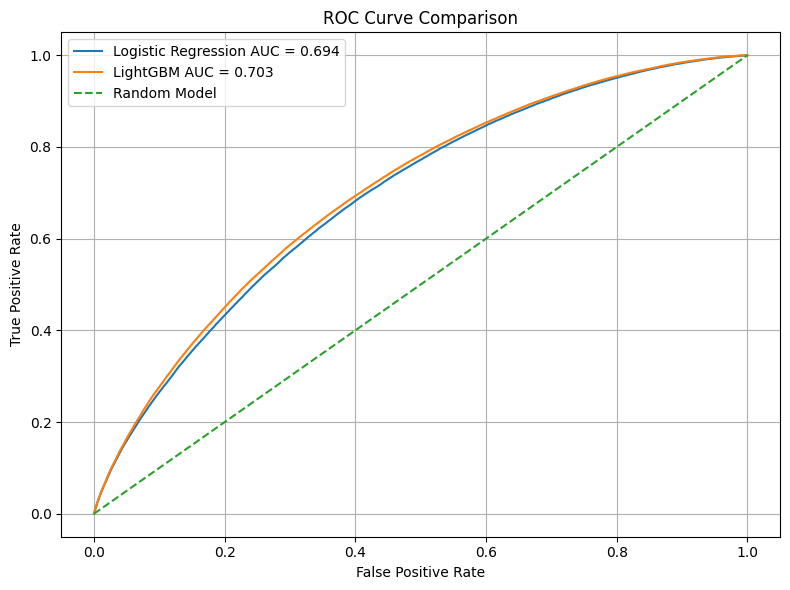

In [4]:
# ROC Curve Comparison
y_test = results_df["actual_default"]
log_pred_prob = results_df["log_pred_prob"]
lgbm_pred_prob = results_df["lgbm_pred_prob"]

log_fpr, log_tpr, _ = roc_curve(y_test, log_pred_prob)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_pred_prob)

log_auc = roc_auc_score(y_test, log_pred_prob)
lgbm_auc = roc_auc_score(y_test, lgbm_pred_prob)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression AUC = {log_auc:.3f}")
plt.plot(lgbm_fpr, lgbm_tpr, label=f"LightGBM AUC = {lgbm_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="Random Model")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../Visual/roc_curve_comparison.png", dpi=300)
plt.show()

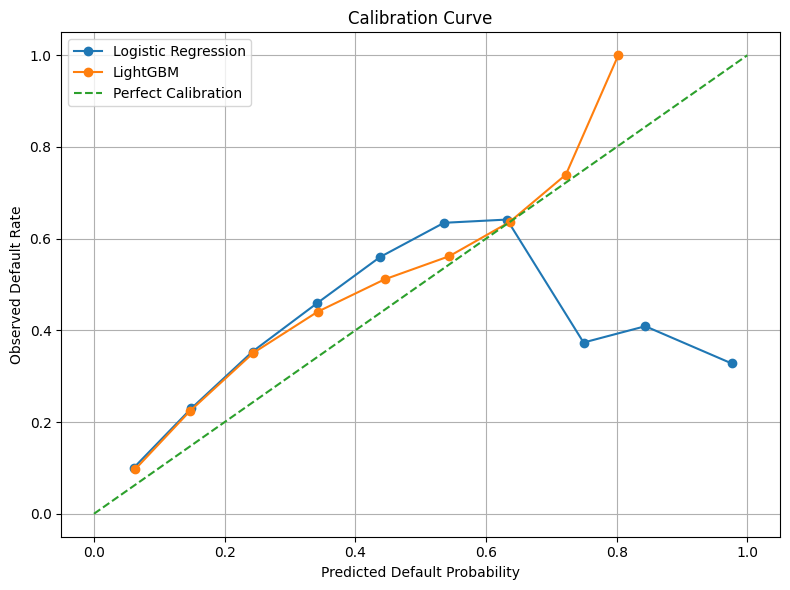

In [5]:
# Calibration Curve Comparison
log_prob_true, log_prob_pred = calibration_curve(
    y_test,
    log_pred_prob,
    n_bins=10
)

lgbm_prob_true, lgbm_prob_pred = calibration_curve(
    y_test,
    lgbm_pred_prob,
    n_bins=10
)

plt.figure(figsize=(8,6))

plt.plot(log_prob_pred, log_prob_true, marker="o", label="Logistic Regression")
plt.plot(lgbm_prob_pred, lgbm_prob_true, marker="o", label="LightGBM")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect Calibration")

plt.title("Calibration Curve")
plt.xlabel("Predicted Default Probability")
plt.ylabel("Observed Default Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../Visual/calibration_curve.png", dpi=300)
plt.show()

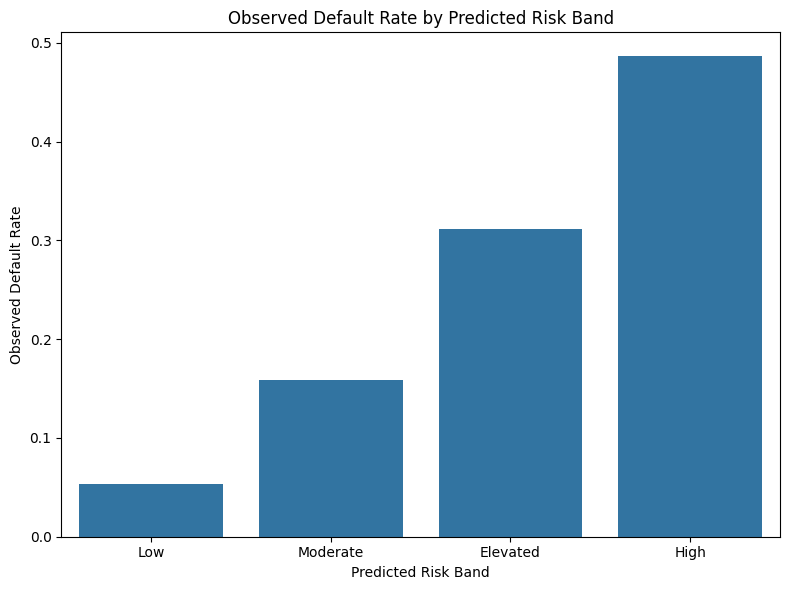

,risk_band,borrower_count,actual_default_rate,avg_predicted_pd
0,Low,46691,0.053179,0.035617
1,Moderate,205617,0.158683,0.102886
2,Elevated,207137,0.311591,0.212505
3,High,83067,0.486475,0.412750


In [6]:
# Risk band default rates
results_df["risk_band"] = pd.cut(
    results_df["lgbm_pred_prob"],
    bins=[0, 0.05, 0.15, 0.30, 1],
    labels=["Low", "Moderate", "Elevated", "High"]
)

risk_band_summary = (
    results_df.groupby("risk_band", observed=False)
    .agg(
        borrower_count=("actual_default", "count"),
        actual_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("lgbm_pred_prob", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=risk_band_summary,
    x="risk_band",
    y="actual_default_rate"
)

plt.title("Observed Default Rate by Predicted Risk Band")
plt.xlabel("Predicted Risk Band")
plt.ylabel("Observed Default Rate")

plt.tight_layout()
plt.savefig("../Visual/risk_band_default_rates.png", dpi=300)
plt.show()

risk_band_summary

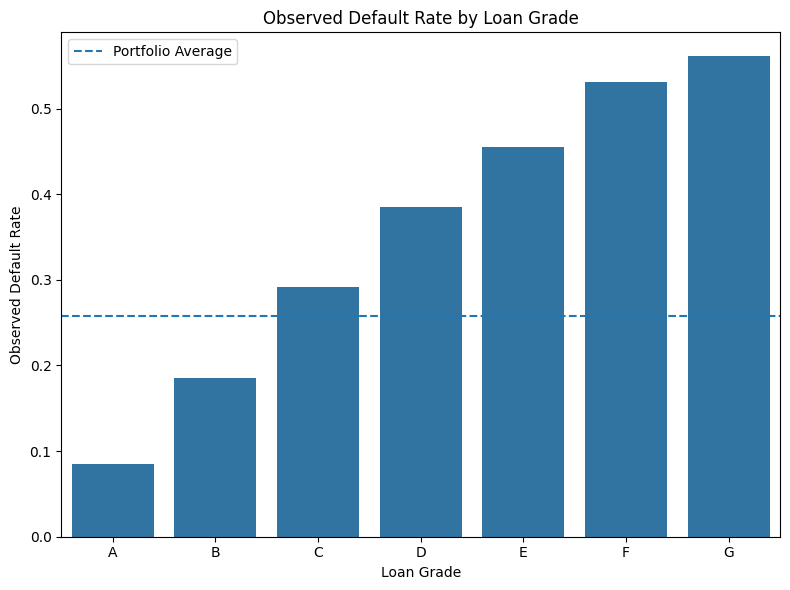

In [7]:
# Default rate by loan grade
grade_default = (
    results_df.groupby("grade")
    .agg(default_rate=("actual_default", "mean"))
    .reset_index()
    .sort_values("grade")
)

portfolio_default_rate = results_df["actual_default"].mean()

plt.figure(figsize=(8,6))

sns.barplot(
    data=grade_default,
    x="grade",
    y="default_rate"
)

plt.axhline(
    portfolio_default_rate,
    linestyle="--",
    label="Portfolio Average"
)

plt.title("Observed Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Observed Default Rate")
plt.legend()

plt.tight_layout()
plt.savefig("../Visual/default_rate_by_grade.png", dpi=300)
plt.show()

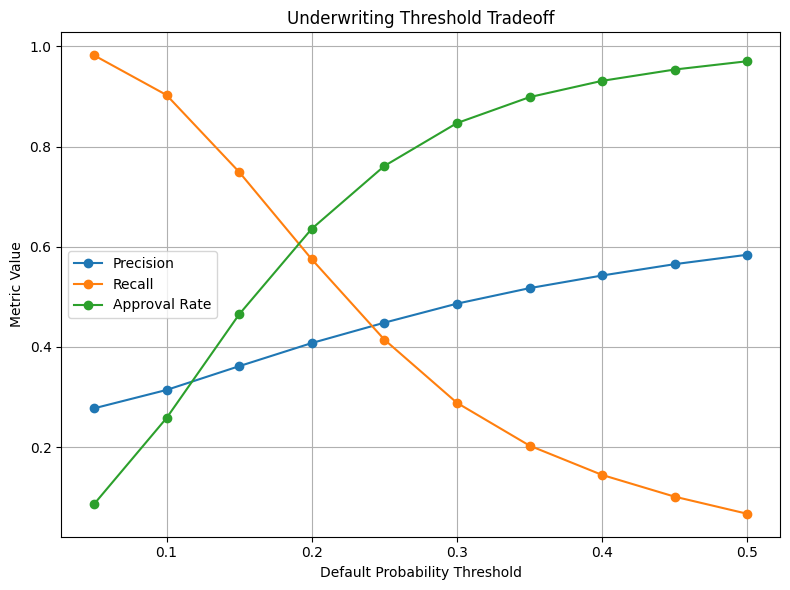

,threshold,precision,recall,approval_rate
0,0.05,0.277479,0.982272,0.086064
1,0.10,0.314211,0.902879,0.258138
2,0.15,0.361649,0.749320,0.465074
3,0.20,0.407811,0.575127,0.635901
4,0.25,0.448488,0.414742,0.761251
5,0.30,0.486475,0.288513,0.846884
6,0.35,0.517427,0.203080,0.898671
7,0.40,0.542667,0.144564,0.931224
8,0.45,0.565308,0.101169,0.953796
9,0.50,0.584106,0.067013,0.970380


In [8]:
# Treshold Tradeoff analysis
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.05, 0.55, 0.05)

threshold_results = []

for threshold in thresholds:
    pred_default = (lgbm_pred_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_default, zero_division=0),
        "recall": recall_score(y_test, pred_default, zero_division=0),
        "approval_rate": (pred_default == 0).mean()
    })

threshold_results = pd.DataFrame(threshold_results)

plt.figure(figsize=(8,6))

plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["approval_rate"], marker="o", label="Approval Rate")

plt.title("Underwriting Threshold Tradeoff")
plt.xlabel("Default Probability Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../Visual/threshold_tradeoff.png", dpi=300)
plt.show()

threshold_results

## Final Business Takeaways

1. The model successfully differentiated higher-risk and lower-risk borrowers using origination-time information.

2. LightGBM improved predictive ranking performance relative to Logistic Regression, while Logistic Regression remained more transparent and easier to explain.

3. Key risk drivers were consistent with credit-risk intuition, including borrower affordability, loan pricing, credit grade, and loan term.

4. Calibration and risk-band analysis helped translate model probabilities into portfolio-monitoring insights.

5. The model is best viewed as a decision-support tool, not an automatic approval/rejection engine.

## Executive Summary

This project developed an end-to-end probability-of-default modeling workflow for consumer lending using LendingClub loan data. The goal was to support fintech underwriting and portfolio risk monitoring by estimating borrower-level default risk using only information available at loan origination.

The analysis began by defining a clean default target, removing unresolved loan outcomes, and excluding post-origination leakage variables. Exploratory analysis showed that default risk was concentrated among lower credit grades, higher interest-rate loans, longer loan terms, and borrowers with weaker affordability profiles.

Two models were developed: Logistic Regression as an interpretable credit-risk benchmark and LightGBM as a nonlinear machine-learning challenger. Model performance was evaluated using ROC-AUC, precision/recall, calibration analysis, and risk-band segmentation.

The final model helped segment borrowers into risk bands with progressively higher observed default rates, demonstrating potential usefulness for underwriting review, portfolio monitoring, and risk-based decision support.

Key limitations include selection bias from approved-loan data, lack of rejected-applicant information, and potential macroeconomic drift over time.

## Model Limitations

1. The data only includes approved LendingClub loans, so the model does not observe rejected applicants.

2. LendingClub borrowers may not represent the full consumer-credit market.

3. Historical default behavior may shift under different macroeconomic conditions.

4. Some potentially valuable variables, such as cash-flow behavior or bank transaction data, were unavailable.

5. Model outputs should support underwriting judgment rather than replace human or policy review.